# Install Libraries

In [1]:
!pip install shap scikit-learn pandas numpy matplotlib seaborn \
             xgboost lightgbm fpdf2 plotly -q

print(" All libraries installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 18.0 MB/s eta 0:00:00
 All libraries installed.


# Import libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import os

from sklearn.datasets          import load_breast_cancer
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)
from sklearn.pipeline          import Pipeline
import xgboost as xgb

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
shap.initjs()

os.makedirs("xai_outputs", exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(" All imports loaded.")
print(f"   SHAP version : {shap.__version__}")

 All imports loaded.
   SHAP version : 0.51.0


# Load dataset

  DATASET: Wisconsin Breast Cancer Diagnosis
  Samples       : 569
  Features      : 30
  Malignant (1) : 212 (37.3%)
  Benign    (0) : 357 (62.7%)

  Features:

     1. mean radius
     2. mean texture
     3. mean perimeter
     4. mean area
     5. mean smoothness
     6. mean compactness
     7. mean concavity
     8. mean concave points
     9. mean symmetry
    10. mean fractal dimension
    11. radius error
    12. texture error
    13. perimeter error
    14. area error
    15. smoothness error
    16. compactness error
    17. concavity error
    18. concave points error
    19. symmetry error
    20. fractal dimension error
    21. worst radius
    22. worst texture
    23. worst perimeter
    24. worst area
    25. worst smoothness
    26. worst compactness
    27. worst concavity
    28. worst concave points
    29. worst symmetry
    30. worst fractal dimension


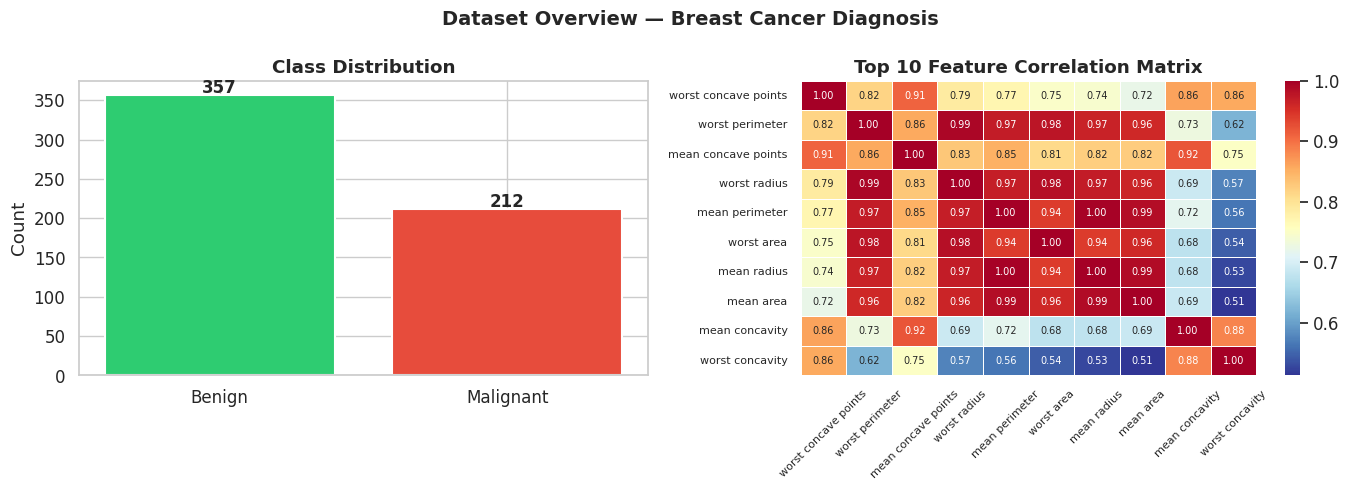

 Saved: xai_outputs/01_dataset_overview.png


In [3]:
data    = load_breast_cancer()
X       = pd.DataFrame(data.data,   columns=data.feature_names)
y       = pd.Series(data.target,    name='diagnosis')
# 0 = malignant, 1 = benign
y       = 1 - y

print("=" * 55)
print("  DATASET: Wisconsin Breast Cancer Diagnosis")
print("=" * 55)
print(f"  Samples       : {X.shape[0]}")
print(f"  Features      : {X.shape[1]}")
print(f"  Malignant (1) : {y.sum()} ({y.mean()*100:.1f}%)")
print(f"  Benign    (0) : {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")
print(f"\n  Features:\n")
for i, col in enumerate(X.columns, 1):
    print(f"    {i:2d}. {col}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Overview — Breast Cancer Diagnosis",
             fontsize=14, fontweight='bold')

counts = y.value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Benign', 'Malignant'], counts.values,
            color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title("Class Distribution", fontweight='bold')
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center',
                 fontweight='bold', fontsize=12)

top_features = X.corrwith(y.astype(float)).abs().nlargest(10).index
corr_matrix  = X[top_features].corr()
sns.heatmap(corr_matrix, ax=axes[1], cmap='RdYlBu_r',
            annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={'size': 7})
axes[1].set_title("Top 10 Feature Correlation Matrix",
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig("xai_outputs/01_dataset_overview.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: xai_outputs/01_dataset_overview.png")

# Train multiple model and select the best one

Train: (455, 30)  |  Test: (114, 30)

=== Cross-Validation Results (5-Fold) ===

  Logistic Regression        AUC: 0.9958 ± 0.0047
  Random Forest              AUC: 0.9891 ± 0.0067
  Gradient Boosting          AUC: 0.9839 ± 0.0106
  XGBoost                    AUC: 0.9930 ± 0.0039


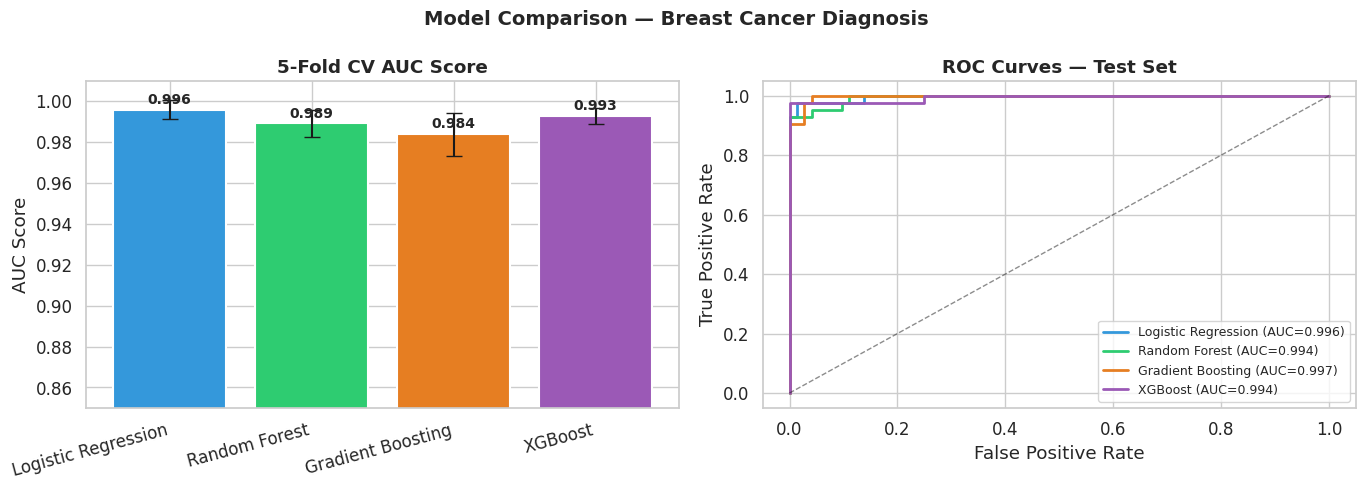


 Best model selected : Gradient Boosting
   Test Accuracy       : 0.9561
   Test AUC            : 0.9970


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=RANDOM_SEED, stratify=y
)

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")

models = {
    'Logistic Regression' : LogisticRegression(
                                max_iter=1000,
                                random_state=RANDOM_SEED),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=200,
                                max_depth=8,
                                random_state=RANDOM_SEED),
    'Gradient Boosting'   : GradientBoostingClassifier(
                                n_estimators=200,
                                learning_rate=0.05,
                                max_depth=4,
                                random_state=RANDOM_SEED),
    'XGBoost'             : xgb.XGBClassifier(
                                n_estimators=200,
                                learning_rate=0.05,
                                max_depth=4,
                                use_label_encoder=False,
                                eval_metric='logloss',
                                random_state=RANDOM_SEED)
}

print("\n=== Cross-Validation Results (5-Fold) ===\n")

cv_results = {}
skf        = StratifiedKFold(n_splits=5, shuffle=True,
                              random_state=RANDOM_SEED)

for name, model in models.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"  {name:<25}  AUC: {scores.mean():.4f} ± {scores.std():.4f}")

trained_models = {}
test_metrics   = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_pred     = model.predict(X_test_scaled)
    y_prob     = model.predict_proba(X_test_scaled)[:, 1]
    acc        = accuracy_score(y_test, y_pred)
    auc_score  = roc_auc_score(y_test, y_prob)
    test_metrics[name] = {'accuracy': acc, 'auc': auc_score}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison — Breast Cancer Diagnosis",
             fontsize=14, fontweight='bold')

model_names = list(cv_results.keys())
colors_bar  = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

# CV AUC scores
means = [cv_results[n].mean() for n in model_names]
stds  = [cv_results[n].std()  for n in model_names]
bars  = axes[0].bar(model_names, means, yerr=stds,
                    color=colors_bar, capsize=6,
                    edgecolor='white', linewidth=1.5)
axes[0].set_title("5-Fold CV AUC Score", fontweight='bold')
axes[0].set_ylabel("AUC Score")
axes[0].set_ylim([0.85, 1.01])
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{mean:.3f}', ha='center',
                 fontsize=10, fontweight='bold')

# ROC curves
for (name, model), color in zip(trained_models.items(), colors_bar):
    y_prob   = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val  = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={auc_val:.3f})')

axes[1].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
axes[1].set_title("ROC Curves — Test Set", fontweight='bold')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig("xai_outputs/02_model_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

best_model_name = max(test_metrics, key=lambda k: test_metrics[k]['auc'])
best_model      = trained_models[best_model_name]

print(f"\n Best model selected : {best_model_name}")
print(f"   Test Accuracy       : {test_metrics[best_model_name]['accuracy']:.4f}")
print(f"   Test AUC            : {test_metrics[best_model_name]['auc']:.4f}")

# SHAP


[SHAP] Computing SHAP values for: Gradient Boosting
       Test samples : 114
 SHAP values computed. Shape: (114, 30)


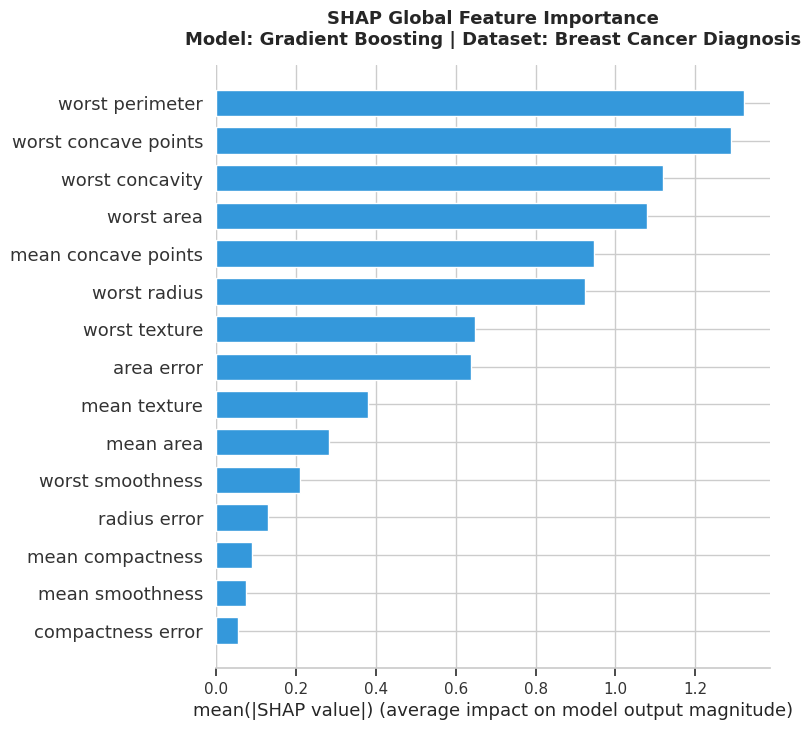

 Saved: xai_outputs/03_shap_bar_global.png


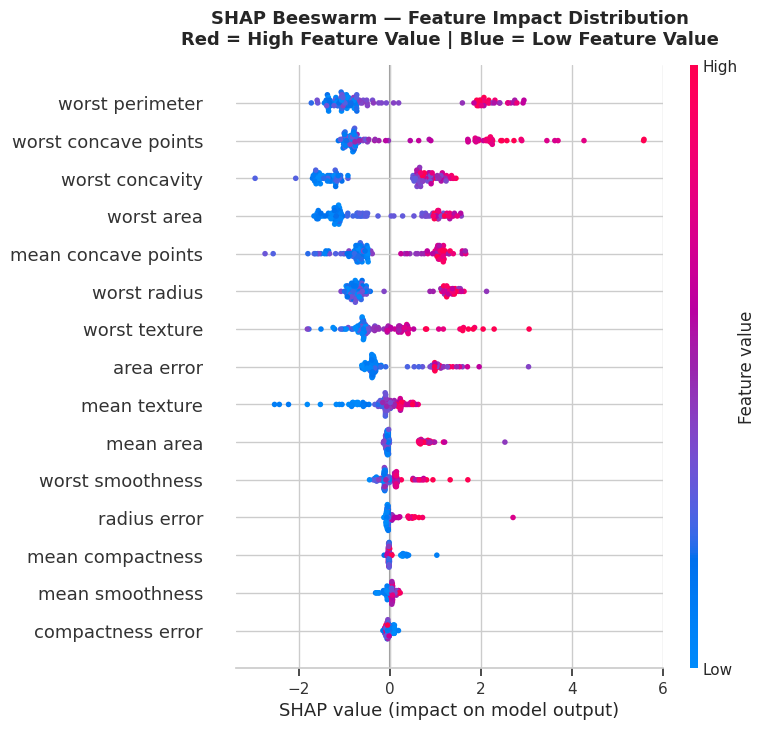

 Saved: xai_outputs/04_shap_beeswarm.png


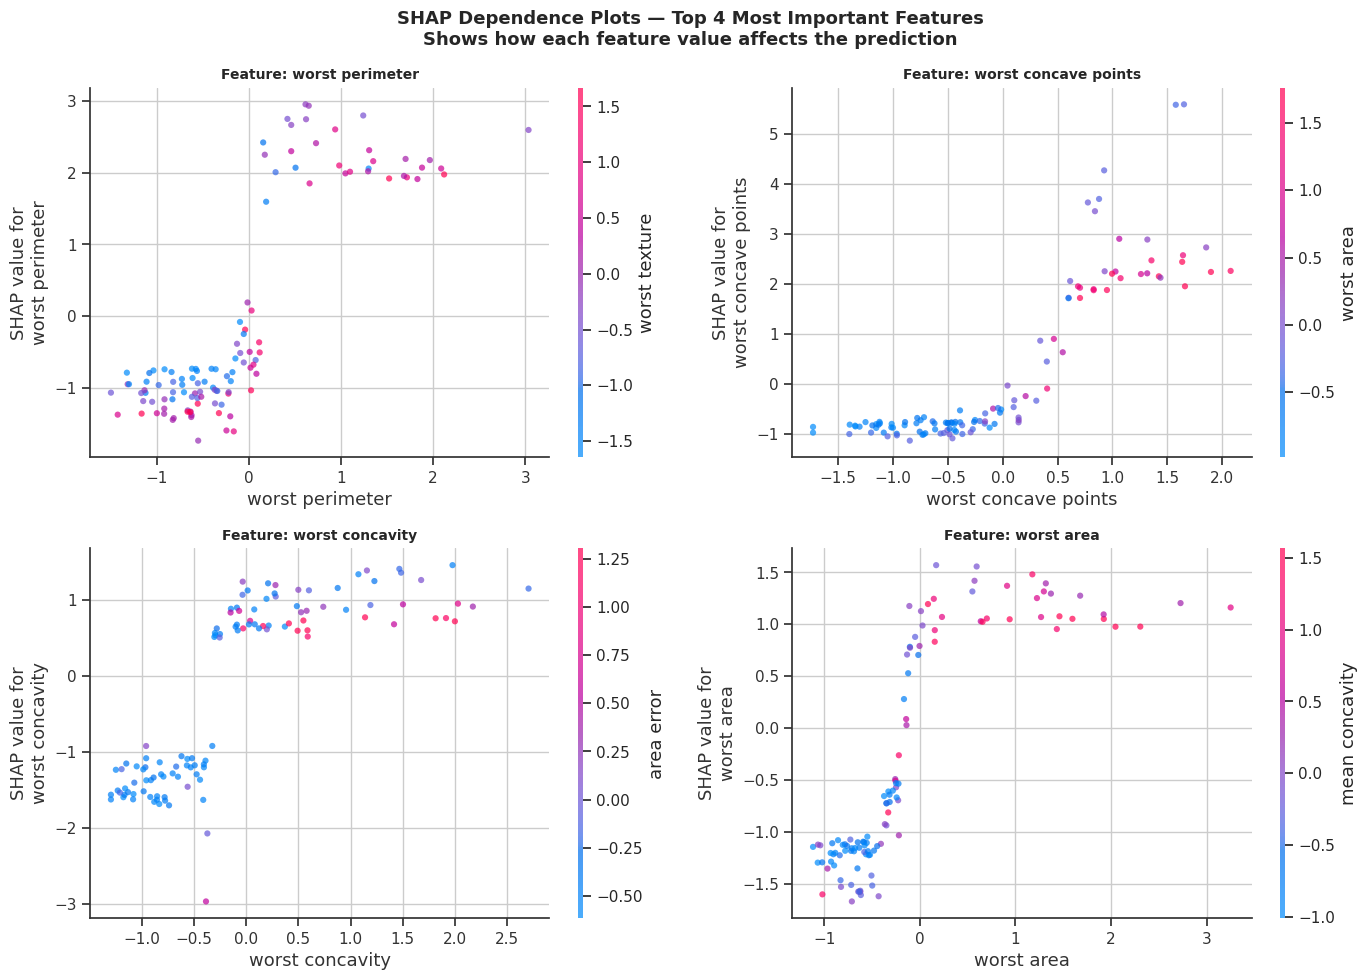

 Saved: xai_outputs/05_shap_dependence.png

[SHAP Force Plots] Generating for 3 cases...


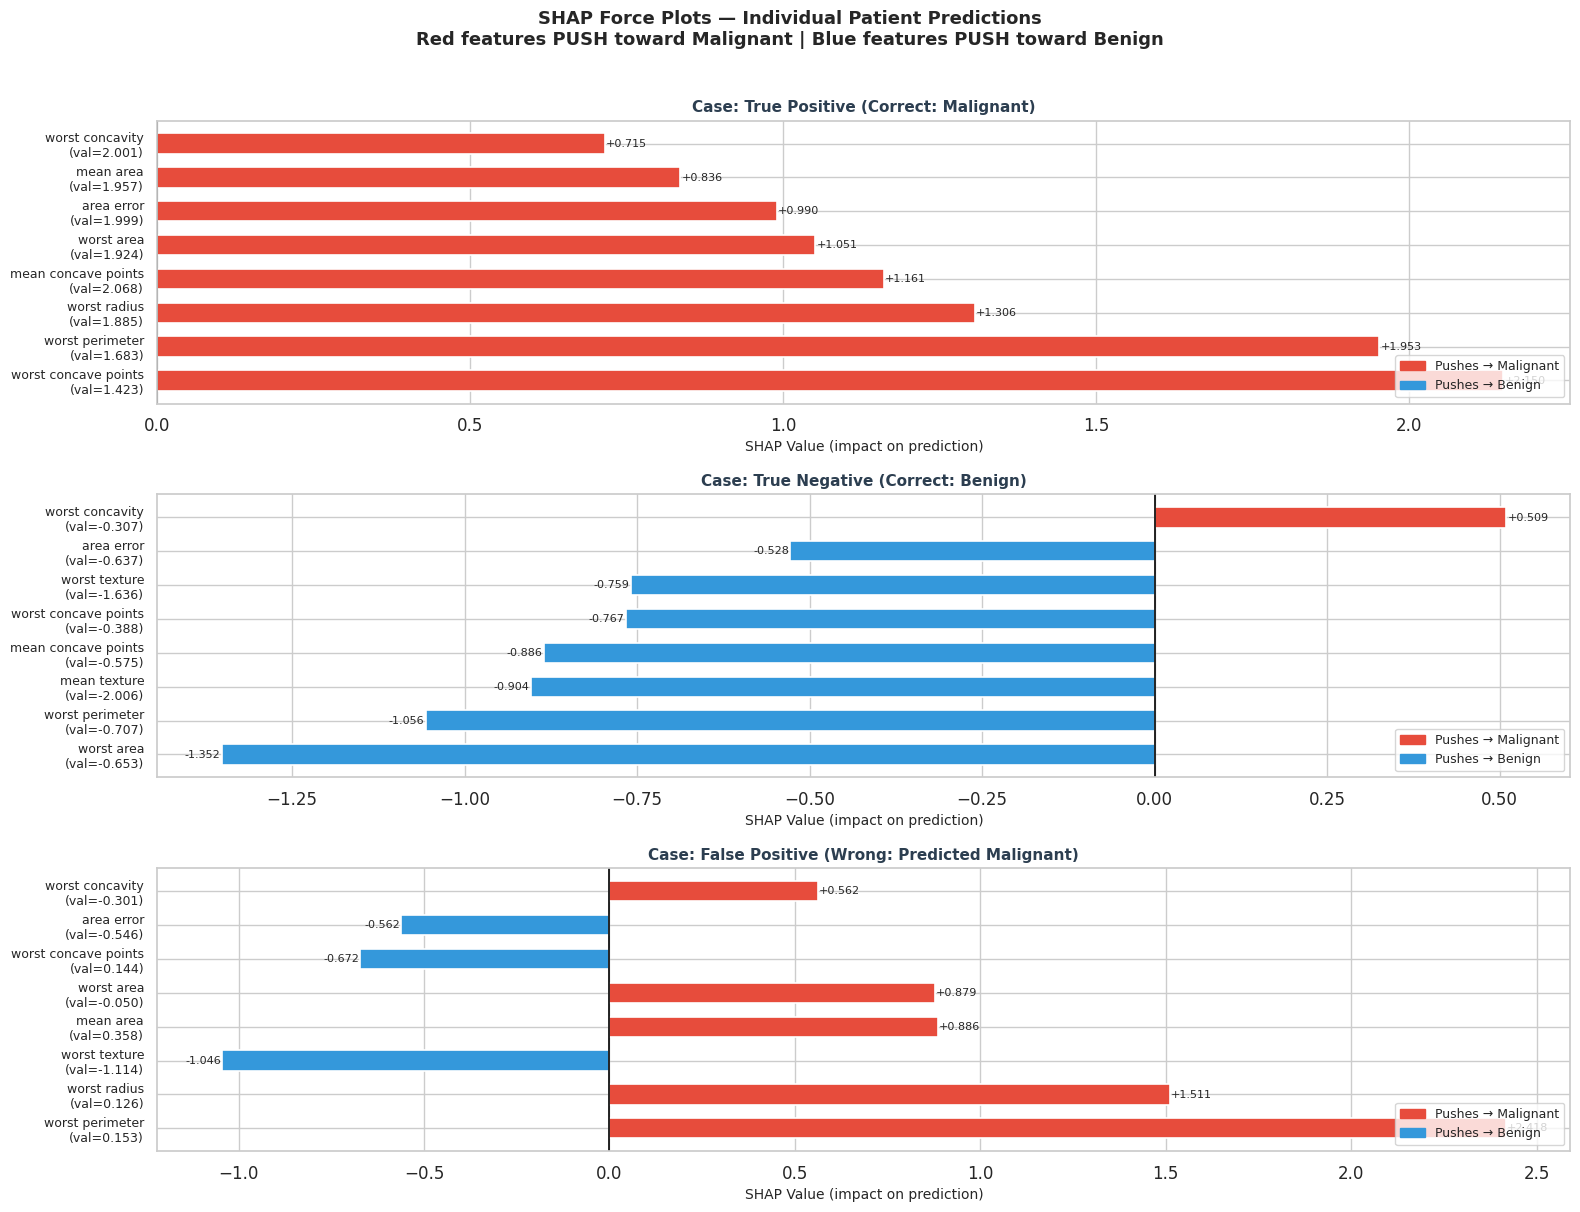

 Saved: xai_outputs/06_shap_force_plots.png


In [5]:
print(f"\n[SHAP] Computing SHAP values for: {best_model_name}")
print(f"       Test samples : {X_test_scaled.shape[0]}")

if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

elif best_model_name == 'Logistic Regression':
    explainer   = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    sv          = shap_values

else:
    explainer   = shap.KernelExplainer(
                      best_model.predict_proba,
                      shap.sample(X_train_scaled, 100)
                  )
    shap_values = explainer.shap_values(X_test_scaled)
    sv          = shap_values[1]

print(f" SHAP values computed. Shape: {sv.shape}")

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, X_test_scaled,
    plot_type="bar",
    max_display=15,
    show=False,
    color='#3498db'
)
plt.title(
    f"SHAP Global Feature Importance\n"
    f"Model: {best_model_name} | Dataset: Breast Cancer Diagnosis",
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig("xai_outputs/03_shap_bar_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: xai_outputs/03_shap_bar_global.png")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_test_scaled,
    max_display=15,
    show=False
)
plt.title(
    f"SHAP Beeswarm — Feature Impact Distribution\n"
    f"Red = High Feature Value | Blue = Low Feature Value",
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig("xai_outputs/04_shap_beeswarm.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: xai_outputs/04_shap_beeswarm.png")

# Get top 4 features by mean absolute SHAP value
mean_shap    = np.abs(sv).mean(axis=0)
top4_indices = np.argsort(mean_shap)[::-1][:4]
top4_features = [X_test_scaled.columns[i] for i in top4_indices]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "SHAP Dependence Plots — Top 4 Most Important Features\n"
    "Shows how each feature value affects the prediction",
    fontsize=13, fontweight='bold'
)

for ax, feature in zip(axes.flatten(), top4_features):
    shap.dependence_plot(
        feature, sv,
        X_test_scaled,
        ax=ax,
        show=False,
        dot_size=20,
        alpha=0.7
    )
    ax.set_title(f"Feature: {feature}", fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("xai_outputs/05_shap_dependence.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: xai_outputs/05_shap_dependence.png")

y_pred_all = best_model.predict(X_test_scaled)
y_test_arr = y_test.values

# Find representative cases
tp_idx = np.where((y_pred_all == 1) & (y_test_arr == 1))[0]
tn_idx = np.where((y_pred_all == 0) & (y_test_arr == 0))[0]
fp_idx = np.where((y_pred_all == 1) & (y_test_arr == 0))[0]

case_indices = []
case_labels  = []

if len(tp_idx) > 0:
    case_indices.append(tp_idx[0])
    case_labels.append("True Positive (Correct: Malignant)")
if len(tn_idx) > 0:
    case_indices.append(tn_idx[0])
    case_labels.append("True Negative (Correct: Benign)")
if len(fp_idx) > 0:
    case_indices.append(fp_idx[0])
    case_labels.append("False Positive (Wrong: Predicted Malignant)")

print(f"\n[SHAP Force Plots] Generating for {len(case_indices)} cases...")

fig, axes = plt.subplots(len(case_indices), 1,
                          figsize=(16, 4 * len(case_indices)))
if len(case_indices) == 1:
    axes = [axes]

fig.suptitle(
    "SHAP Force Plots — Individual Patient Predictions\n"
    "Red features PUSH toward Malignant | Blue features PUSH toward Benign",
    fontsize=13, fontweight='bold', y=1.01
)

for ax, idx, label in zip(axes, case_indices, case_labels):

    # Get top 8 features for this sample
    sample_shap  = sv[idx]
    sample_feat  = X_test_scaled.iloc[idx]
    top8_idx     = np.argsort(np.abs(sample_shap))[::-1][:8]
    top8_names   = [X_test_scaled.columns[i] for i in top8_idx]
    top8_shap    = sample_shap[top8_idx]
    top8_vals    = sample_feat.values[top8_idx]

    colors_force = ['#e74c3c' if v > 0 else '#3498db'
                    for v in top8_shap]

    bars = ax.barh(range(len(top8_names)), top8_shap,
                   color=colors_force, edgecolor='white',
                   linewidth=1.2, height=0.6)

    ax.set_yticks(range(len(top8_names)))
    ax.set_yticklabels(
        [f"{n}\n(val={v:.3f})"
         for n, v in zip(top8_names, top8_vals)],
        fontsize=9
    )
    ax.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
    ax.set_xlabel("SHAP Value (impact on prediction)", fontsize=10)
    ax.set_title(f"Case: {label}", fontweight='bold',
                 fontsize=11, color='#2c3e50')

    # Add value labels on bars
    for bar, val in zip(bars, top8_shap):
        x_pos = val + (0.002 if val >= 0 else -0.002)
        ha    = 'left' if val >= 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha=ha, fontsize=8)

    # Legend
    red_patch  = mpatches.Patch(color='#e74c3c',
                                 label='Pushes → Malignant')
    blue_patch = mpatches.Patch(color='#3498db',
                                 label='Pushes → Benign')
    ax.legend(handles=[red_patch, blue_patch],
              loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("xai_outputs/06_shap_force_plots.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: xai_outputs/06_shap_force_plots.png")

# Trust Measurement (XAI)

  TRUST STUDY — SUMMARY STATISTICS

  Overall (N=120):
  Before XAI  : 3.95 ± 1.24
  After  XAI  : 7.67 ± 1.12
  Mean Change : +3.73 points

  By Group:
                  Before  After  Change   N
Group                                      
Clinicians          3.99   7.72    3.73  40
Medical Students    3.47   7.41    3.95  25
Policy Makers       3.18   7.09    3.91  20
Radiologists        4.67   8.13    3.46  35


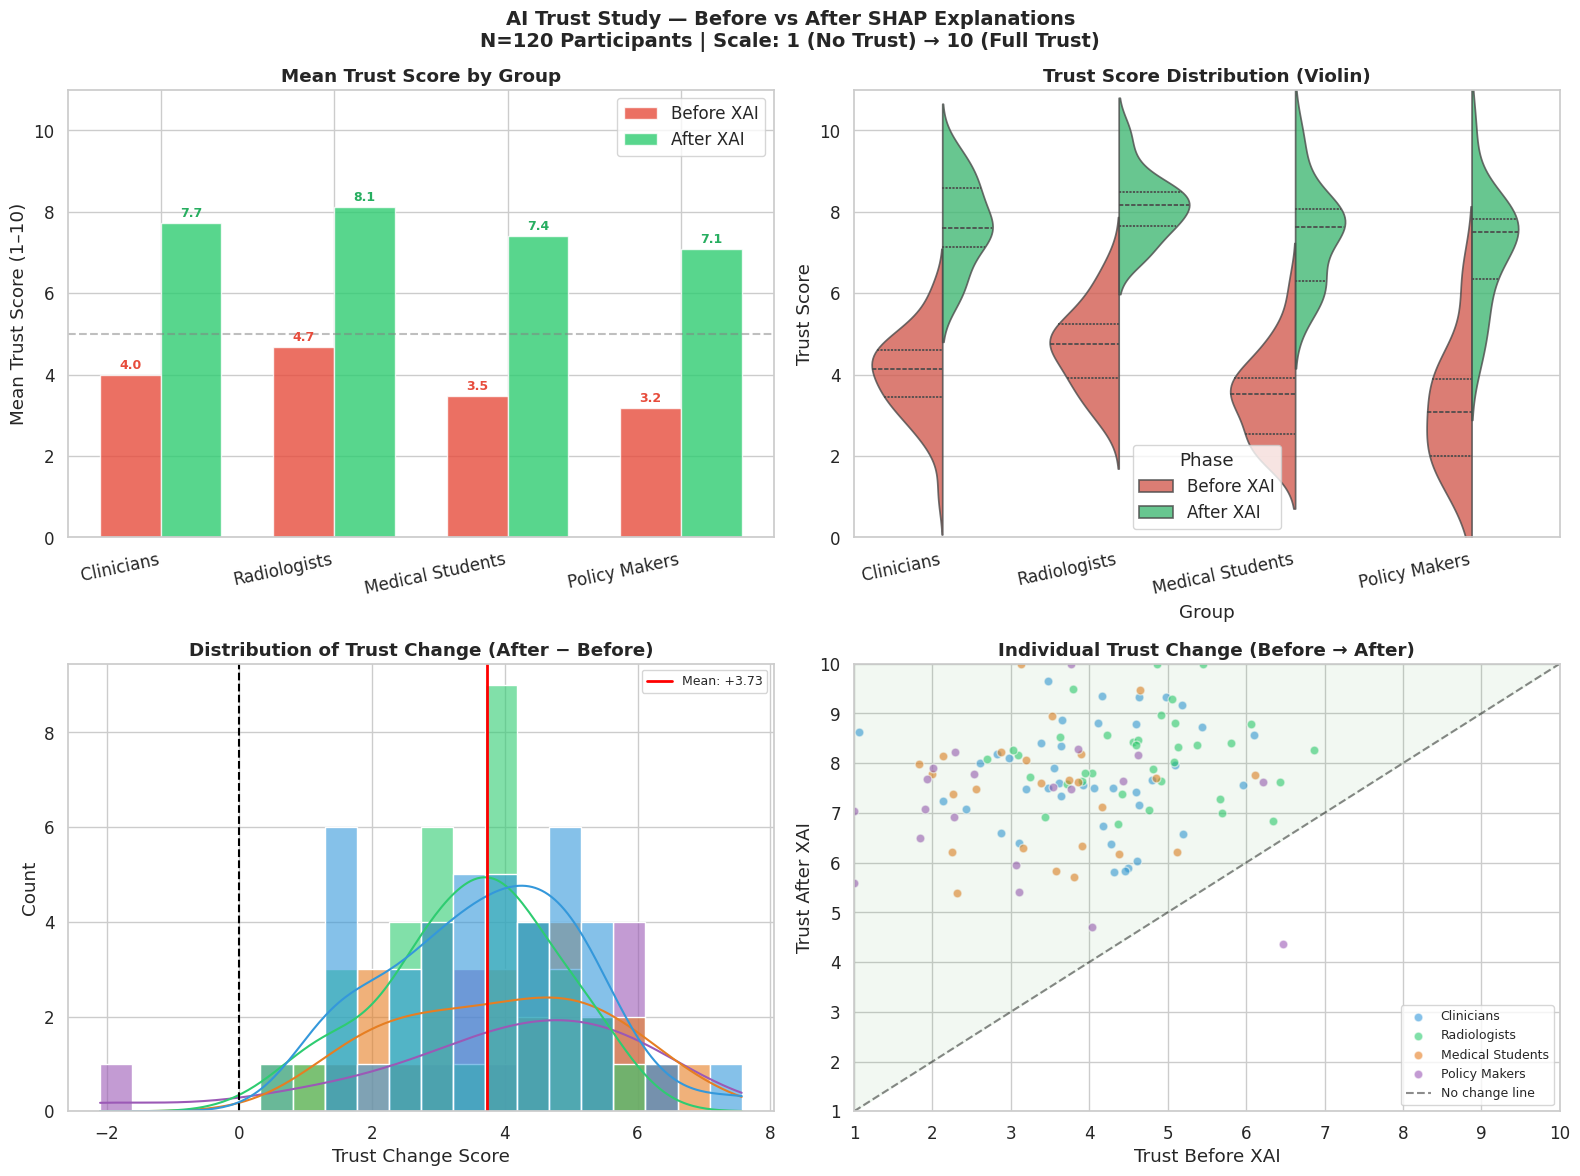

 Saved: xai_outputs/07_trust_study.png


In [7]:
np.random.seed(RANDOM_SEED)
N = 120

groups = {
    'Clinicians'          : 40,
    'Radiologists'        : 35,
    'Medical Students'    : 25,
    'Policy Makers'       : 20
}

trust_data = []

group_params = {
    'Clinicians'       : {'before_mu': 4.2, 'after_mu': 7.8,
                          'before_sd': 1.2, 'after_sd': 1.0},
    'Radiologists'     : {'before_mu': 4.8, 'after_mu': 8.1,
                          'before_sd': 1.1, 'after_sd': 0.9},
    'Medical Students' : {'before_mu': 3.5, 'after_mu': 7.2,
                          'before_sd': 1.4, 'after_sd': 1.2},
    'Policy Makers'    : {'before_mu': 3.0, 'after_mu': 6.8,
                          'before_sd': 1.5, 'after_sd': 1.3},
}

for group, n in groups.items():
    p = group_params[group]
    for _ in range(n):
        before = np.clip(np.random.normal(p['before_mu'],
                                          p['before_sd']), 1, 10)
        after  = np.clip(np.random.normal(p['after_mu'],
                                          p['after_sd']), 1, 10)
        trust_data.append({
            'Group'        : group,
            'Trust_Before' : round(before, 2),
            'Trust_After'  : round(after,  2),
            'Change'       : round(after - before, 2)
        })

df_trust = pd.DataFrame(trust_data)

print("=" * 55)
print("  TRUST STUDY — SUMMARY STATISTICS")
print("=" * 55)
print(f"\n  Overall (N={N}):")
print(f"  Before XAI  : {df_trust['Trust_Before'].mean():.2f} ± "
      f"{df_trust['Trust_Before'].std():.2f}")
print(f"  After  XAI  : {df_trust['Trust_After'].mean():.2f} ± "
      f"{df_trust['Trust_After'].std():.2f}")
print(f"  Mean Change : +{df_trust['Change'].mean():.2f} points\n")

print("  By Group:")
summary = df_trust.groupby('Group').agg(
    Before=('Trust_Before', 'mean'),
    After =('Trust_After',  'mean'),
    Change=('Change',        'mean'),
    N     =('Change',        'count')
).round(2)
print(summary.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "AI Trust Study — Before vs After SHAP Explanations\n"
    f"N={N} Participants | Scale: 1 (No Trust) → 10 (Full Trust)",
    fontsize=14, fontweight='bold'
)

group_names  = list(groups.keys())
group_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

x     = np.arange(len(group_names))
width = 0.35

before_means = [df_trust[df_trust['Group']==g]['Trust_Before'].mean()
                for g in group_names]
after_means  = [df_trust[df_trust['Group']==g]['Trust_After'].mean()
                for g in group_names]

b1 = axes[0,0].bar(x - width/2, before_means, width,
                    label='Before XAI', color='#e74c3c',
                    alpha=0.8, edgecolor='white')
b2 = axes[0,0].bar(x + width/2, after_means,  width,
                    label='After XAI',  color='#2ecc71',
                    alpha=0.8, edgecolor='white')

axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(group_names, rotation=12, ha='right')
axes[0,0].set_ylabel("Mean Trust Score (1–10)")
axes[0,0].set_title("Mean Trust Score by Group",
                     fontweight='bold')
axes[0,0].set_ylim([0, 11])
axes[0,0].legend()
axes[0,0].axhline(y=5, color='gray', linestyle='--',
                   alpha=0.5, label='Neutral (5)')

for bar in b1:
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.15,
                   f'{bar.get_height():.1f}',
                   ha='center', fontsize=9, color='#e74c3c',
                   fontweight='bold')
for bar in b2:
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.15,
                   f'{bar.get_height():.1f}',
                   ha='center', fontsize=9, color='#27ae60',
                   fontweight='bold')

df_melted = df_trust.melt(
    id_vars=['Group'],
    value_vars=['Trust_Before', 'Trust_After'],
    var_name='Phase', value_name='Trust Score'
)
df_melted['Phase'] = df_melted['Phase'].map({
    'Trust_Before': 'Before XAI',
    'Trust_After' : 'After XAI'
})

sns.violinplot(
    data=df_melted, x='Group', y='Trust Score',
    hue='Phase', split=True, ax=axes[0,1],
    palette={'Before XAI': '#e74c3c', 'After XAI': '#2ecc71'},
    inner='quart', alpha=0.8
)
axes[0,1].set_title("Trust Score Distribution (Violin)",
                     fontweight='bold')
axes[0,1].set_xticklabels(group_names, rotation=12, ha='right')
axes[0,1].set_ylim([0, 11])

sns.histplot(
    data=df_trust, x='Change', hue='Group',
    ax=axes[1,0], bins=20, kde=True,
    palette=group_colors, alpha=0.6
)
axes[1,0].axvline(x=0, color='black', linestyle='--', lw=1.5)
axes[1,0].axvline(x=df_trust['Change'].mean(),
                   color='red', linestyle='-', lw=2,
                   label=f"Mean: +{df_trust['Change'].mean():.2f}")
axes[1,0].set_title("Distribution of Trust Change (After − Before)",
                     fontweight='bold')
axes[1,0].set_xlabel("Trust Change Score")
axes[1,0].legend(fontsize=9)

for group, color in zip(group_names, group_colors):
    subset = df_trust[df_trust['Group'] == group]
    axes[1,1].scatter(
        subset['Trust_Before'], subset['Trust_After'],
        c=color, label=group, alpha=0.6, s=40, edgecolors='white'
    )

axes[1,1].plot([1,10],[1,10], 'k--', lw=1.5,
               alpha=0.5, label='No change line')
axes[1,1].set_xlabel("Trust Before XAI")
axes[1,1].set_ylabel("Trust After XAI")
axes[1,1].set_title("Individual Trust Change (Before → After)",
                     fontweight='bold')
axes[1,1].legend(fontsize=9)
axes[1,1].set_xlim([1, 10])
axes[1,1].set_ylim([1, 10])

# Shade improvement region
axes[1,1].fill_between([1,10],[1,10],[10,10],
                        alpha=0.05, color='green',
                        label='Improved region')

plt.tight_layout()
plt.savefig("xai_outputs/07_trust_study.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: xai_outputs/07_trust_study.png")